<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Segmentation%20using%20a%20clustering%20algorithm(KNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
#Generate a dataset that mimicks the Kenyan One we desire
np.random.seed(42)
sns.set_theme(style="whitegrid")
def generate_kenyan_retail_data(n_samples=5000):
    """
    Generates a synthetic dataset mimicking a Kenyan retail chain.
    Features: Age, Monthly_Income_KES, Annual_Spend_KES, Visit_Frequency_Yearly, Avg_Basket_Size_KES
    """
    # Define cluster profiles based on Kenyan market realities
    # Format: [Age, Monthly_Income_KES, Annual_Spend_KES, Visit_Freq, Avg_Basket_Size_KES]
    # [Mean, StdDev] for each feature

    # Cluster 0: "Kadogo" Regulars (35% of data = 1750)
    # Low-mid income, high frequency, low basket size
    c0_means = [35,40000,120000,120,800]
    c0_stds = [8,10000,30000,30,200]

    # Cluster 1: Affluent Suburbanites (20% of data = 1000)
    # High income, medium frequency, high basket size
    c1_means = [42,250000,900000,50,15000]
    c1_stds = [7,50000,200000,15,4000]

    # Cluster 2: Bulk Buyers / "Upcountry" (15% of data = 750)
    # Middle income, low frequency, very high basket size
    c2_means = [45,80000,400000,12,30000]
    c2_stds = [10,20000,100000,5,8000]

    # Cluster 3: Urban Youth / Students (30% of data = 1500)
    # Low income, low-medium frequency, low basket size
    c3_means =[22,15000,45000,40,1000]
    c3_stds = [4,8000,20000,15,300]

    #Geberate data for each cluster
    data = []
    labels = []

    for i,(means,stds,size) in enumerate([
        (c0_means,c0_stds,1750),
        (c1_means,c1_stds,1000),
        (c2_means,c2_stds,750),
        (c3_means,c3_stds,1500)
    ]):
       cluster_data = np.random.normal(means,stds,size=(size,5))
       # Ensure no negative values for realistic financial/age data
       cluster_data = np.abs(cluster_data)
       data.append(cluster_data)
       labels.extend([i]*size)

    X = np.vstack(data)
    y_true = np.array(labels)

    #Create DataFrame
    df =pd.DataFrame(X,columns=['Age','Monthly_Income_KES','Annual_Spend_KES','Visit_Frequency_Yearly','Avg_Basket_Size_KES'])

    # Round values to realistic numbers

    df['Age'] = df['Age'].astype(int)
    df['Monthly_Income_KES'] = (df['Monthly_Income_KES']/1000).round() * 1000
    df['Annual_Spend_KES'] = (df['Annual_Spend_KES'] / 1000).round() * 1000
    df['Visit_Frequency_Yearly'] = df['Visit_Frequency_Yearly'].astype(int)
    df['Avg_Basket_Size_KES'] = (df['Avg_Basket_Size_KES'] / 50).round() * 50


    return df,y_true

# Generate the data
df,true_labels = generate_kenyan_retail_data()
print("Dataset Generated Successfully!")
print(df.head(),"\n")

Dataset Generated Successfully!
   Age  Monthly_Income_KES  Annual_Spend_KES  Visit_Frequency_Yearly  \
0   38             39000.0          139000.0                     165   
1   33             56000.0          143000.0                     105   
2   31             35000.0          127000.0                      62   
3   30             30000.0          129000.0                      92   
4   46             38000.0          122000.0                      77   

   Avg_Basket_Size_KES  
0                750.0  
1                900.0  
2                450.0  
3                500.0  
4                700.0   



In [3]:
#.2.Preprocessing & Clustering
# Select features for clustering (excluding Age for the core clustering to focus on financial/behavioral metrics,
# but we keep it in the df for profiling later)
features_for_clustering = ['Monthly_Income_KES','Annual_Spend_KES','Visit_Frequency_Yearly','Avg_Basket_Size_KES']
X_cluster = df[features_for_clustering]

#Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

#Apply K Means
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil_avg = silhouette_score(X_scaled,df['Cluster'])
print(f"K-Means Clustering Complete. Silhouette Score:{sil_avg:.3f}\n")

K-Means Clustering Complete. Silhouette Score:0.645



In [4]:
#3. Analysis and Profiling
# Calculate the mean of all features for each cluster to understand their profiles
cluster_profile = df.groupby('Cluster').mean()

# Map clusters to our business personas (Note: KMeans labels clusters 0-3 arbitrarily,
# so we map them based on their characteristics)
persona_map = {}
for cluster_id in cluster_profile.index:
  income = cluster_profile.loc[cluster_id,'Monthly_Income_KES']
  freq = cluster_profile.loc[cluster_id,'Visit_Frequency_Yearly']
  basket=cluster_profile.loc[cluster_id,'Avg_Basket_Size_KES']

  if income > 150000:
    persona_map[cluster_id]="1.Affluent Subarbanites"
  elif freq>80 and basket<2000:
    persona_map[cluster_id]="0.'Kadogo'Regulars"
  elif freq <20 and basket >20000:
    persona_map[cluster_id]="2.Bulk Buyers"
  else:
    persona_map[cluster_id] = "3.Urban Youth/Students"

df['Persona'] = df['Cluster'].map(persona_map)

print("--CLUSTER PROFILES(Averages)---")
print(cluster_profile.round(0))
print("\n---PERSONA MAPPING---")
for k,v in persona_map.items():
  count=len(df[df['Cluster']==k])
  print(f"Cluster{k}({count}customers)->{v}")

--CLUSTER PROFILES(Averages)---
          Age  Monthly_Income_KES  Annual_Spend_KES  Visit_Frequency_Yearly  \
Cluster                                                                       
0        42.0            251420.0          889415.0                    49.0   
1        23.0             18458.0           55858.0                    43.0   
2        35.0             40151.0          119882.0                   125.0   
3        45.0             81638.0          399938.0                    12.0   

         Avg_Basket_Size_KES  
Cluster                       
0                    15150.0  
1                     1010.0  
2                      804.0  
3                    30307.0  

---PERSONA MAPPING---
Cluster0(998customers)->1.Affluent Subarbanites
Cluster1(1719customers)->3.Urban Youth/Students
Cluster2(1540customers)->0.'Kadogo'Regulars
Cluster3(743customers)->2.Bulk Buyers


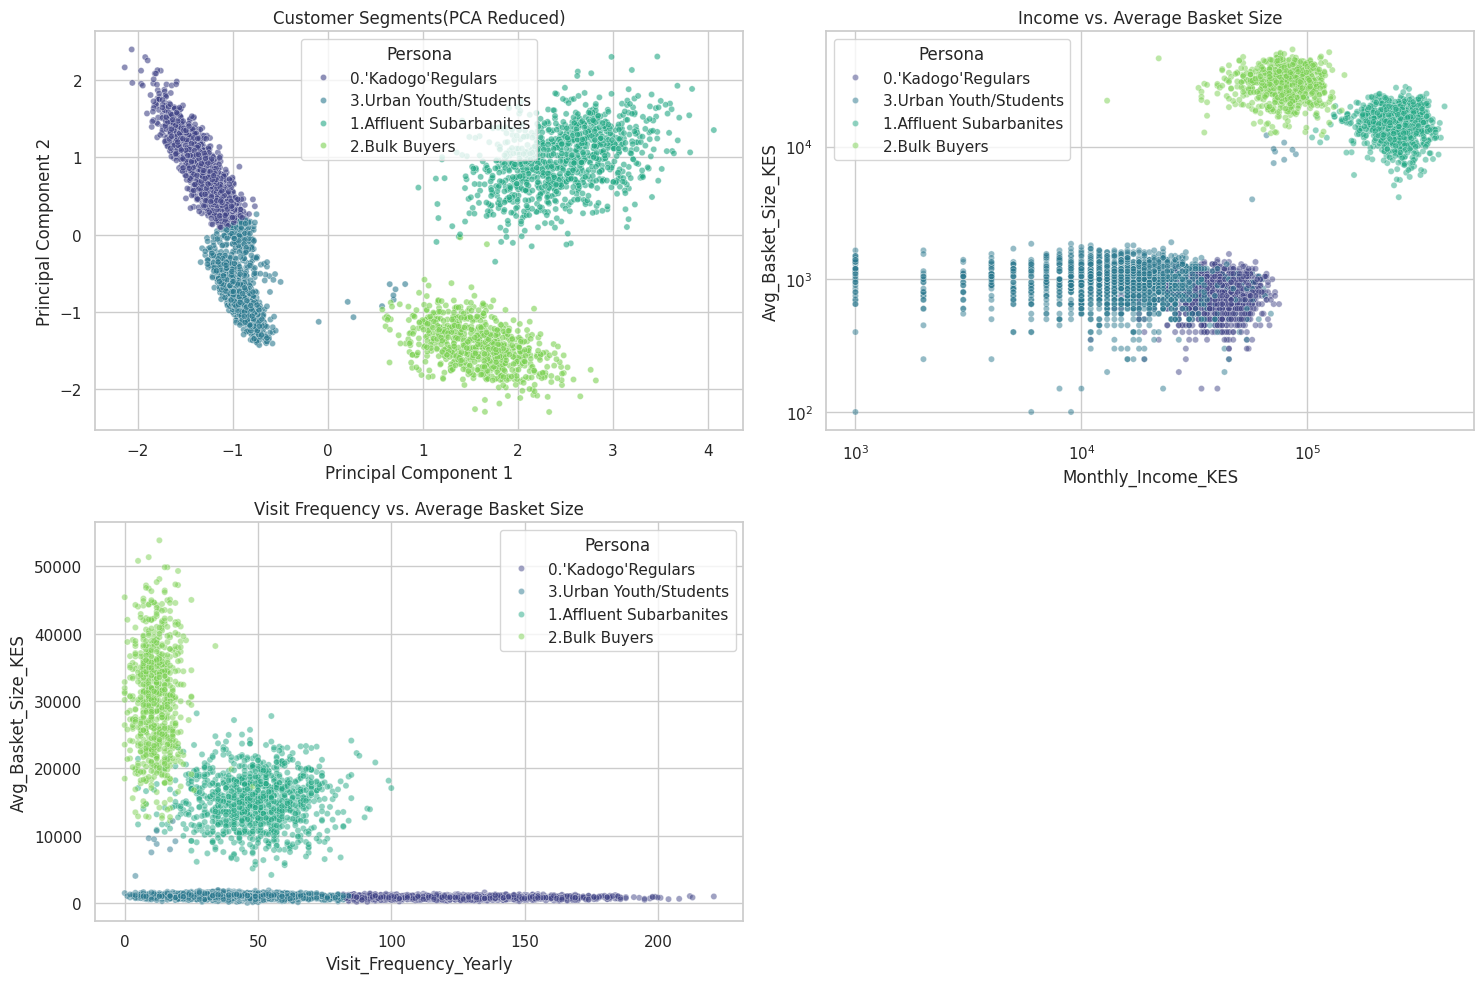

In [7]:
#.4 Visualization
# Use PCA clustering to reduce 4D clustering features for 2D visualization

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
df['PCA1'] = principal_components[:, 0]
df['PCA2'] = principal_components[:, 1]

#Plot 1:PCA Scatter Plot
plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)
sns.scatterplot(x='PCA1',y='PCA2',hue='Persona',data=df,palette='viridis',alpha=0.6,s=20)
plt.title('Customer Segments(PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

#Plot 2:Income vs Basket Size
plt.subplot(2,2,2)
sns.scatterplot(x='Monthly_Income_KES',y='Avg_Basket_Size_KES',hue='Persona',data=df,palette='viridis',alpha=0.5,s=20)
plt.title('Income vs. Average Basket Size')
plt.xscale('log')
plt.yscale('log')

#Plot 3:Visit Frequency vs Basket Size
plt.subplot(2,2,3)
sns.scatterplot(x='Visit_Frequency_Yearly',y='Avg_Basket_Size_KES',hue='Persona',data=df,palette = 'viridis',alpha=0.5,s=20)
plt.title('Visit Frequency vs. Average Basket Size')
plt.tight_layout()
plt.show()

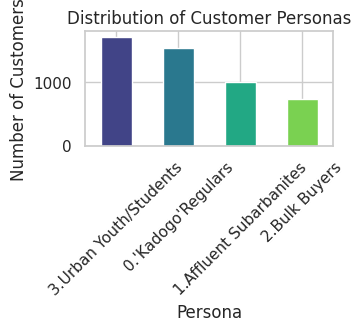

In [9]:
import matplotlib.pyplot as plt

# Plot 4: Cluster Distribution
plt.subplot(2,2,4)
df['Persona'].value_counts().plot(kind='bar',color=sns.color_palette('viridis',4))
plt.title('Distribution of Customer Personas')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()